# Energy Attribution Visualizations for HPC Libraries

Publication-quality figures showing how GPU energy is distributed across
**compute libraries** (rocBLAS, rocSOLVER, HIP Runtime) and the **functions** within them.

MPI communication and HPL CPU-side orchestration are excluded entirely:
the instrumentation inserts device syncs to enable exclusive per-call attribution,
which prevents the CPU from scheduling ahead on the GPU command queue.
This makes idle overhead a measurement artifact, not real application behaviour.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
from ampere import Ensemble, MetricConfig, MetricType, connect

# -- Publication style --
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})

BG = '#fafafa'

connect(server="localhost", port=5555)

/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/arkouda/core/client.py:860: RuntimeWarning: Version mismatch between client (2026.02.02+40.gec39a6ec8) and server (2026.02.02.1); this may cause some commands to fail or behave incorrectly! Updating arkouda is strongly recommended.
  warnings.warn(
connected to arkouda server tcp://*:5555


    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          
Client Version: 2026.02.02+40.gec39a6ec8Connecting to Arkouda server at localhost:5555...


In [2]:
# ── Load traces ──────────────────────────────────────────────
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def my_hpc_topology(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

ranks = [f"MPI Rank {i}" for i in range(8)]
topo  = {"Node0": ranks}
# ensemble = Ensemble.from_trace_paths(["./hpl-captured-params"], topo, configs)
ensemble = Ensemble.from_trace_paths(["./hpg-mxp-2"], topo, configs)

Loading Runs: 100%|██████████| 1/1 [01:18<00:00, 78.41s/it]


In [3]:
# ── Attribution: energy (Joules) and power (W) per function call ──
devices = [
    "A2rocm_smi:::energy_count:device=0",
    "A2rocm_smi:::energy_count:device=2",
    "A2rocm_smi:::energy_count:device=4",
    "A2rocm_smi:::energy_count:device=6",
]

import arkouda as ak

df_joules = ak.DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, strategy='exclusive')
    for m in devices
])

df_power = ak.DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, output_mode='rate', strategy='exclusive')
    for m in devices
])

time_profile = ensemble.time_profile(topology_resolver=my_hpc_topology, strategy='exclusive')

# Convert to pandas for plotting
energy  = df_joules.to_pandas()
power   = df_power.to_pandas()
timep   = time_profile.to_pandas()

# Compute duration
energy['Duration'] = energy['End Time'] - energy['Start Time']
power['Duration']  = power['End Time']  - power['Start Time']

print(f"Total attributed energy calls: {len(energy):,}")
print(f"Total energy: {energy['Value'].sum():,.1f} J")

Attributing 'A2rocm_smi:::energy_count:device=0' on Arkouda Server...


100%|██████████| 1/1 [00:07<00:00,  7.79s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' on Arkouda Server...


100%|██████████| 1/1 [00:07<00:00,  7.33s/it]


Attributing 'A2rocm_smi:::energy_count:device=4' on Arkouda Server...


...

Attributing 'A2rocm_smi:::energy_count:device=6' on Arkouda Server...


100%|██████████| 1/1 [00:07<00:00,  7.77s/it]


Profiling time on Arkouda Server...


100%|██████████| 1/1 [00:37<00:00, 37.07s/it]


This will transfer 1 GB from arkouda to pandas.This will transfer 1 GB from arkouda to pandas.This will transfer 1 GB from arkouda to pandas.Total attributed energy calls: 17,443,960
Total energy: 56,265.6 J


In [4]:
# -- Classify functions into compute libraries vs idle overhead --
# Idle = MPI comms + HPL orchestration + main.  These are CPU-side phases
# where the GPU sits idle.  Because our instrumentation inserts device syncs
# to get exclusive per-call attribution, idle time is artificially inflated
# (the CPU cannot schedule ahead), making it a measurement artifact.
# We drop it entirely.

def classify_library(name):
    n = name.lower()
    if n.startswith('mpi_'):                                       return '_idle'
    if n.startswith('hpl_') or n == 'main':                        return '_idle'
    if n.startswith('devicectx') or n.startswith('vector'):        return '_idle'
    if n.startswith('void setup'):                                 return '_idle'
    if n.startswith('fence'):                                      return '_idle'
    if 'rocblas' in n:                                             return 'rocBLAS'
    if 'rocsolver' in n:                                           return 'rocSOLVER'
    if (n.startswith('hip') or 'hipmalloc' in n
        or 'hipcheck' in n or 'devicemalloc' in n
        or 'hostmalloc' in n):                                     return 'HIP Runtime'
    return 'Other'

def short_name(name):
    paren = name.find('(')
    return name[:paren] if paren != -1 else name

for df in (energy, power, timep):
    df['Library']   = df['Name'].apply(classify_library)
    df['ShortName'] = df['Name'].apply(short_name)

# Drop idle entirely -- it is a sync-insertion artifact
compute_energy = energy[energy['Library'] != '_idle'].copy()
compute_power  = power[power['Library']  != '_idle'].copy()
compute_time   = timep[timep['Library']  != '_idle'].copy()

# Drop tiny-duration noise (< 1 ms)
MIN_DUR = 1e-4
compute_energy_sig = compute_energy[compute_energy['Duration'] >= MIN_DUR].copy()
compute_power_sig  = compute_power[compute_power['Duration']   >= MIN_DUR].copy()

# -- Palette (consistent across all figures) --
LIB_PALETTE = {
    'rocBLAS':      '#2d6a4f',
    'rocSOLVER':    '#e07a3a',
    'HIP Runtime':  '#9b5de5',
    'Other':        '#457b9d',
}
LIB_ORDER = ['rocBLAS', 'rocSOLVER', 'HIP Runtime', 'Other']

print("Compute-library energy breakdown:")
print(compute_energy.groupby('Library')['Value'].sum()
      .sort_values(ascending=False).to_string())
print(f"\nSignificant calls (>= 1 ms): {len(compute_energy_sig):,}")

Compute-library energy breakdown:
Library
rocBLAS    9890.870324
Other      4967.037727

Significant calls (>= 1 ms): 1,777,935


## Figure 1 -- Nested Donut: Library and Function Energy Breakdown

Inner ring = energy share by compute library; outer ring = individual functions.
All GPU-idle overhead (MPI, HPL orchestration) is excluded.

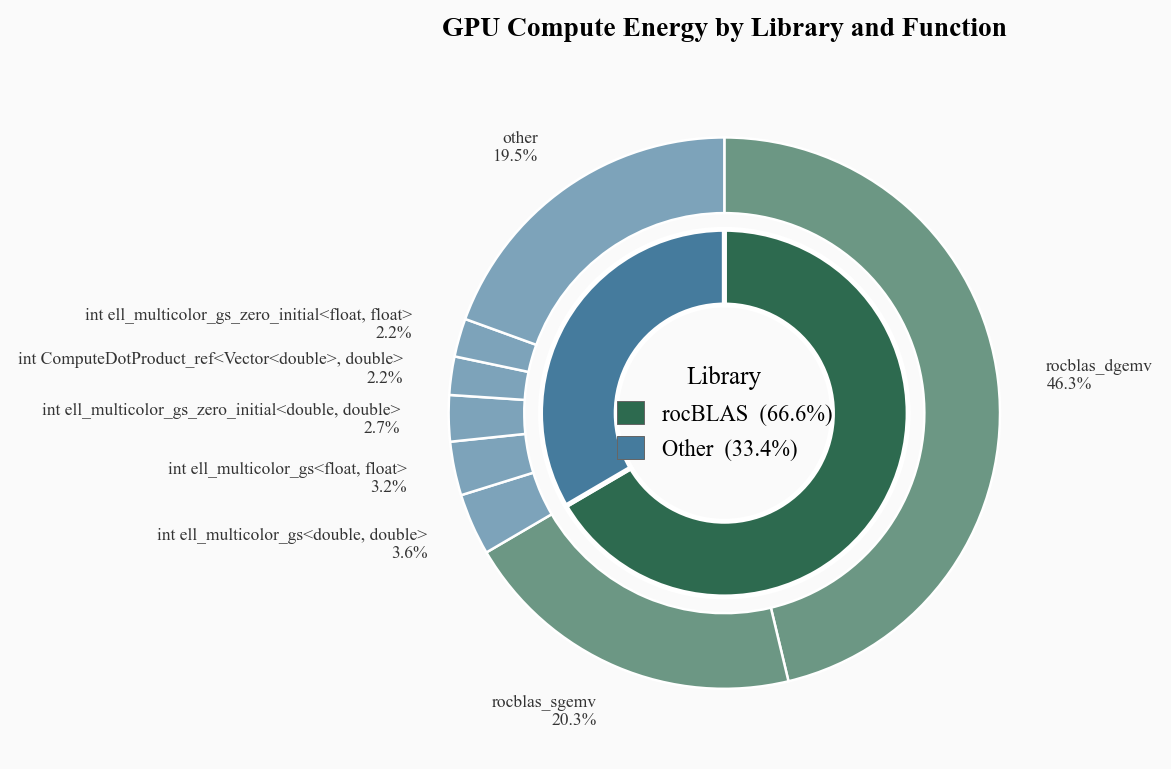

In [5]:
# -- Fig 1: Nested donut -- Library -> Function energy hierarchy --

lib_energy = compute_energy.groupby('Library')['Value'].sum().sort_values(ascending=False)
lib_order  = [l for l in LIB_ORDER if l in lib_energy.index]
lib_energy = lib_energy.reindex(lib_order).dropna()

func_energy = (compute_energy.groupby(['Library', 'ShortName'])['Value']
               .sum().reset_index()
               .sort_values(['Library', 'Value'], ascending=[True, False]))

TOP_PER_LIB = 5
outer_labels, outer_vals, outer_colors = [], [], []
for lib in lib_order:
    sub = func_energy[func_energy['Library'] == lib]
    top = sub.head(TOP_PER_LIB)
    rest_val = sub.iloc[TOP_PER_LIB:]['Value'].sum() if len(sub) > TOP_PER_LIB else 0
    for _, row in top.iterrows():
        outer_labels.append(row['ShortName'])
        outer_vals.append(row['Value'])
        outer_colors.append(LIB_PALETTE[lib])
    if rest_val > 0:
        outer_labels.append('other')
        outer_vals.append(rest_val)
        outer_colors.append(LIB_PALETTE[lib])

def lighten(hex_color, factor=0.30):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(c + (1 - c) * factor for c in rgb)

outer_colors_light = [lighten(c) for c in outer_colors]

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor=BG)
ax.set_facecolor(BG)

wedges_inner, _ = ax.pie(
    lib_energy.values, labels=None,
    colors=[LIB_PALETTE[l] for l in lib_order],
    radius=0.68, wedgeprops=dict(width=0.28, edgecolor='white', linewidth=2),
    startangle=90, counterclock=False)

wedges_outer, _ = ax.pie(
    outer_vals, labels=None, colors=outer_colors_light,
    radius=1.02, wedgeprops=dict(width=0.28, edgecolor='white', linewidth=1),
    startangle=90, counterclock=False)

total = sum(outer_vals)
for wedge, label, val in zip(wedges_outer, outer_labels, outer_vals):
    pct = val / total * 100
    if pct < 2.0:
        continue
    angle = (wedge.theta2 + wedge.theta1) / 2
    r = 1.20
    x = r * np.cos(np.radians(angle))
    y = r * np.sin(np.radians(angle))
    ha = 'left' if x >= 0 else 'right'
    ax.annotate(f'{label}\n{pct:.1f}%', xy=(x, y), fontsize=7,
                ha=ha, va='center', color='#333333')

handles = [mpatches.Patch(facecolor=LIB_PALETTE[l], edgecolor='#666',
           linewidth=0.4, label=f'{l}  ({lib_energy[l]/total*100:.1f}%)')
           for l in lib_order]
ax.legend(handles=handles, loc='center', frameon=False, fontsize=9,
          title='Library', title_fontsize=10, handlelength=1.2, handleheight=1.2)

ax.set_title('GPU Compute Energy by Library and Function', pad=16, fontweight='bold')
fig.tight_layout()
plt.savefig('fig1_nested_donut.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 2 -- Energy Share vs. Time Share

Paired lollipop: each library's share of **energy** (red) vs **time** (blue).
A gap between the two dots means the library is drawing disproportionate power
relative to its runtime.

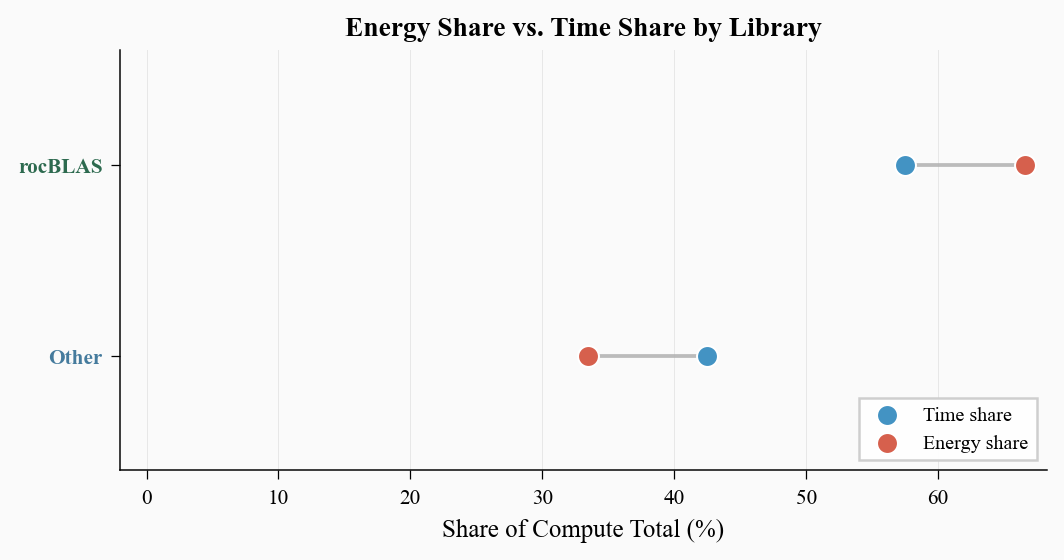

In [6]:
# -- Fig 2: Paired lollipop -- Energy % vs Time % per library --

e_by_lib = compute_energy.groupby('Library')['Value'].sum()
e_frac   = (e_by_lib / e_by_lib.sum() * 100)

t_by_lib = compute_time.groupby('Library')['Value'].sum()
t_frac   = (t_by_lib / t_by_lib.sum() * 100)

order = e_frac.sort_values(ascending=True).index.tolist()
e_frac = e_frac.reindex(order, fill_value=0)
t_frac = t_frac.reindex(order, fill_value=0)
y_pos = np.arange(len(order))

fig, ax = plt.subplots(figsize=(6, 3.2), facecolor=BG)
ax.set_facecolor(BG)

for i, lib in enumerate(order):
    ax.plot([t_frac[lib], e_frac[lib]], [i, i],
            color='#bbbbbb', linewidth=1.5, zorder=1, solid_capstyle='round')

ax.scatter(t_frac.values, y_pos, s=70, color='#4393c3', zorder=3,
           edgecolors='white', linewidths=0.8, label='Time share')
ax.scatter(e_frac.values, y_pos, s=70, color='#d6604d', zorder=3,
           edgecolors='white', linewidths=0.8, label='Energy share')

ax.set_yticks(y_pos)
ax.set_yticklabels(order)
for i, lib in enumerate(order):
    ax.get_yticklabels()[i].set_color(LIB_PALETTE.get(lib, '#333'))
    ax.get_yticklabels()[i].set_fontweight('semibold')

ax.set_xlabel('Share of Compute Total (%)')
ax.set_title('Energy Share vs. Time Share by Library', fontweight='bold')
ax.legend(loc='lower right', frameon=True, fancybox=False,
          edgecolor='#ccc', framealpha=0.95, fontsize=8)
ax.grid(axis='x', alpha=0.25)
ax.set_xlim(left=-2)
ax.set_ylim(-0.6, len(order) - 0.4)

fig.tight_layout()
plt.savefig('fig2_energy_vs_time.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 3 -- Ridgeline: Per-Call Power Distribution

Overlapping density plots for the top energy-consuming functions.
Reveals whether a function has consistent power draw or high variance.

/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_23433/2210762561.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


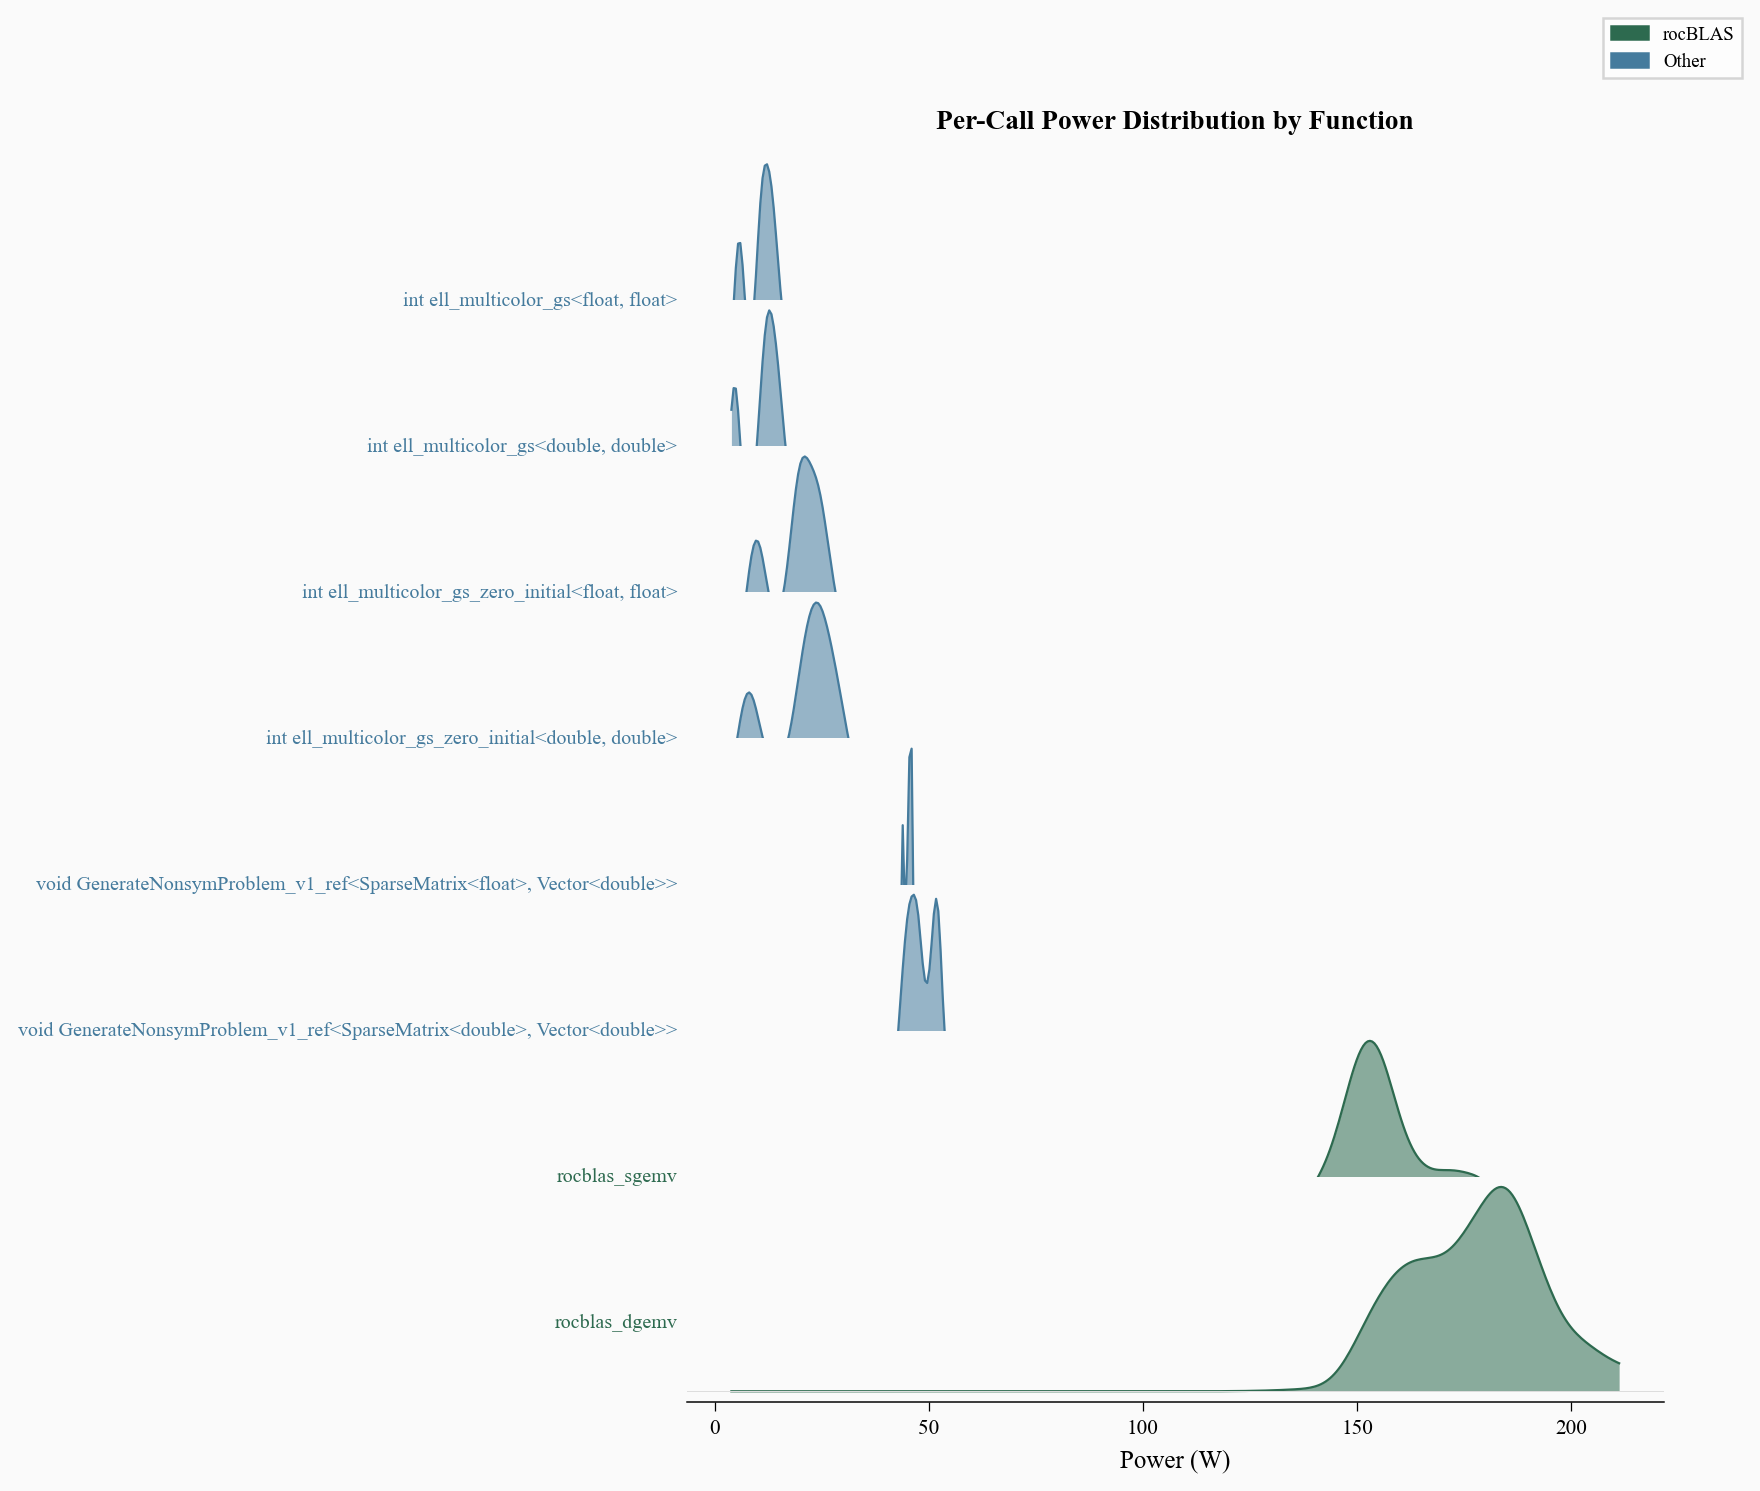

In [7]:
# -- Fig 3: Ridgeline -- Power distribution per function --
from scipy.stats import gaussian_kde

top_funcs_e = (compute_energy_sig.groupby('ShortName')['Value'].sum()
               .sort_values(ascending=False).head(8).index.tolist())

ridge_data = compute_power_sig[compute_power_sig['ShortName'].isin(top_funcs_e)].copy()

func_order = (ridge_data.groupby('ShortName')['Value']
              .median().reindex(top_funcs_e).sort_values(ascending=True).index.tolist())

n_funcs = len(func_order)
fig, axes = plt.subplots(n_funcs, 1, figsize=(7, 1.05 * n_funcs + 0.6),
                         sharex=True, gridspec_kw={'hspace': -0.35},
                         facecolor=BG)

all_vals = ridge_data['Value'].dropna()
x_lo, x_hi = all_vals.quantile(0.005), all_vals.quantile(0.995)
x_grid = np.linspace(x_lo, x_hi, 400)

for i, func in enumerate(func_order):
    ax = axes[i]
    ax.set_facecolor(BG)
    vals = ridge_data[ridge_data['ShortName'] == func]['Value'].dropna().values
    lib  = ridge_data[ridge_data['ShortName'] == func]['Library'].iloc[0]
    color = LIB_PALETTE.get(lib, '#888')

    if len(vals) > 5:
        try:
            kde = gaussian_kde(vals, bw_method=0.25)
            density = kde(x_grid)
            density = density / density.max()
        except Exception:
            density = np.zeros_like(x_grid)
    else:
        density = np.zeros_like(x_grid)

    ax.fill_between(x_grid, density, alpha=0.55, color=color, linewidth=0)
    ax.plot(x_grid, density, color=color, linewidth=0.9)
    ax.axhline(0, color='#dddddd', linewidth=0.4)

    ax.set_yticks([])
    ax.set_ylim(bottom=-0.05)
    ax.text(-0.01, 0.35, func, transform=ax.transAxes, ha='right', va='center',
            fontsize=8, fontweight='medium', color=color)

    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel('Power (W)')
axes[-1].spines['bottom'].set_visible(True)
axes[0].set_title('Per-Call Power Distribution by Function', fontweight='bold', pad=10)

legend_handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l)
                  for l in LIB_ORDER if l in ridge_data['Library'].values]
fig.legend(handles=legend_handles, loc='upper right', frameon=True,
           fancybox=False, edgecolor='#ccc', fontsize=7.5,
           bbox_to_anchor=(0.97, 0.97))

fig.tight_layout()
plt.savefig('fig3_ridgeline_power.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 4 -- Temporal Energy Heatmap

Rank x Time heatmap of energy intensity. Only compute phases are coloured;
time bins where no compute library was active appear in light grey.

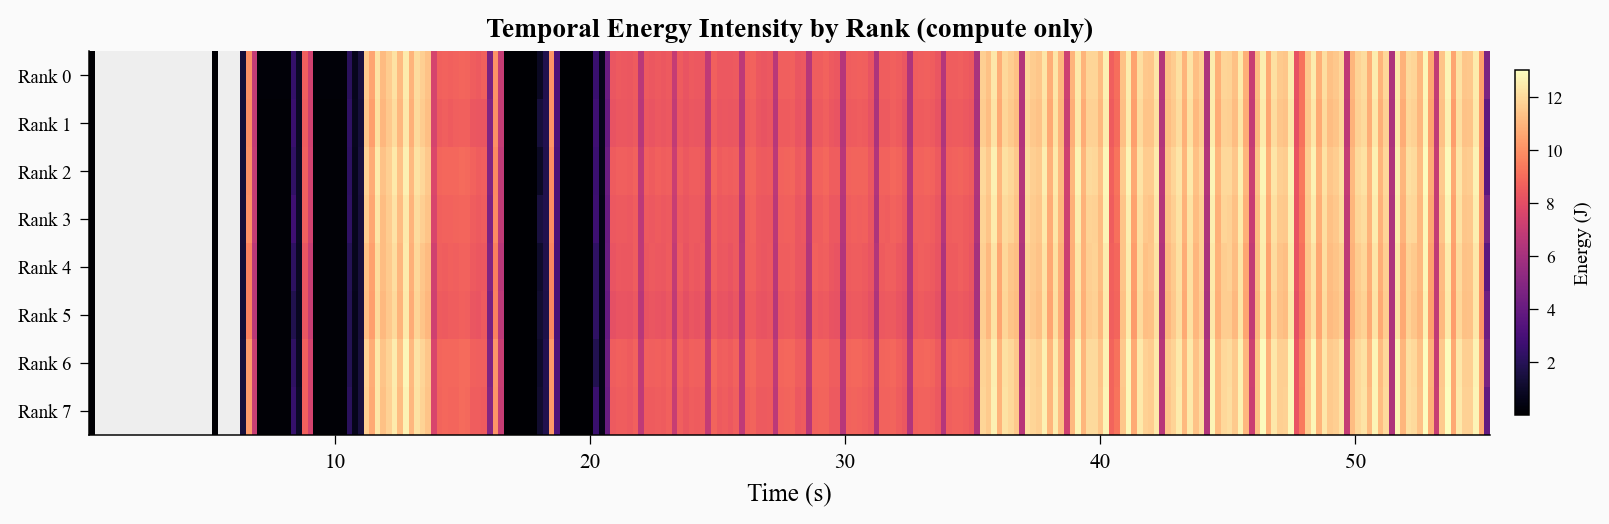

In [8]:
# -- Fig 4: Temporal energy heatmap (vectorised) --

N_BINS = 250
t_min = compute_energy['Start Time'].min()
t_max = compute_energy['End Time'].max()
bin_edges = np.linspace(t_min, t_max, N_BINS + 1)

rank_names = sorted(compute_energy['Rank'].unique())
heat = np.full((len(rank_names), N_BINS), np.nan)

starts   = compute_energy['Start Time'].values
ends     = compute_energy['End Time'].values
vals     = compute_energy['Value'].values
ranks_arr = compute_energy['Rank'].values

for ri, rname in enumerate(rank_names):
    mask = ranks_arr == rname
    s, e, v = starts[mask], ends[mask], vals[mask]
    dur = e - s
    ok = dur > 0
    s, e, v, dur = s[ok], e[ok], v[ok], dur[ok]
    i0 = np.clip(np.searchsorted(bin_edges, s, side='right') - 1, 0, N_BINS - 1)
    i1 = np.clip(np.searchsorted(bin_edges, e, side='left'), 0, N_BINS)
    for j in range(len(s)):
        for bi in range(i0[j], i1[j]):
            overlap = min(e[j], bin_edges[bi+1]) - max(s[j], bin_edges[bi])
            contrib = v[j] * overlap / dur[j]
            if np.isnan(heat[ri, bi]):
                heat[ri, bi] = contrib
            else:
                heat[ri, bi] += contrib

masked_heat = np.ma.masked_invalid(heat)

fig, ax = plt.subplots(figsize=(10, 3), facecolor=BG)
ax.set_facecolor(BG)
cmap = plt.cm.magma.copy()
cmap.set_bad('#eeeeee')

im = ax.pcolormesh(bin_edges, np.arange(len(rank_names) + 1), masked_heat,
                   cmap=cmap, shading='flat', rasterized=True)
ax.set_yticks(np.arange(len(rank_names)) + 0.5)
ax.set_yticklabels([r.replace('MPI ', '') for r in rank_names], fontsize=7.5)
ax.set_xlabel('Time (s)')
ax.set_title('Temporal Energy Intensity by Rank (compute only)', fontweight='bold')
ax.invert_yaxis()

cbar = fig.colorbar(im, ax=ax, pad=0.015, aspect=25, shrink=0.9)
cbar.set_label('Energy (J)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
plt.savefig('fig4_temporal_heatmap.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 5 -- Per-Rank Energy by Library

Stacked horizontal bars showing library-level energy per MPI rank.
Reveals load balance across the node.

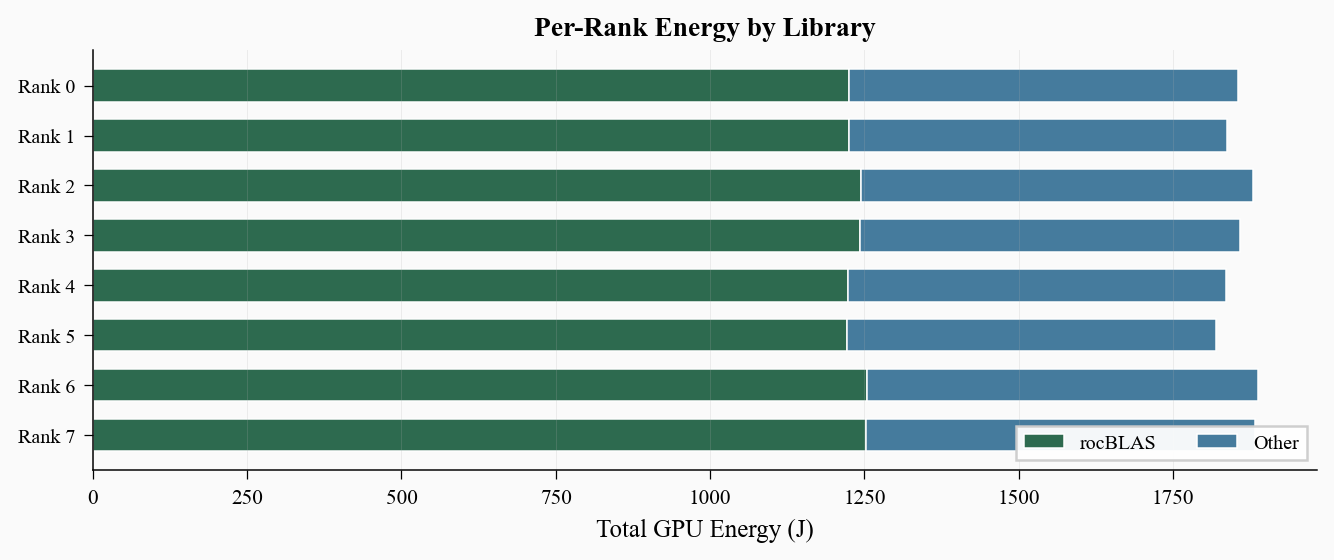

In [9]:
# -- Fig 5: Stacked horizontal bar -- per-rank library energy --

pivot = (compute_energy.groupby(['Rank', 'Library'])['Value']
         .sum().unstack(fill_value=0))
cols = [c for c in LIB_ORDER if c in pivot.columns]
pivot = pivot[cols].reindex(sorted(pivot.index))

fig, ax = plt.subplots(figsize=(7.5, 3.2), facecolor=BG)
ax.set_facecolor(BG)

left = np.zeros(len(pivot))
for lib in cols:
    v = pivot[lib].values
    ax.barh(np.arange(len(pivot)), v, left=left, color=LIB_PALETTE[lib],
            edgecolor='white', linewidth=0.6, label=lib, height=0.65)
    left += v

ax.set_yticks(np.arange(len(pivot)))
ax.set_yticklabels([r.replace('MPI ', '') for r in pivot.index], fontsize=8)
ax.set_xlabel('Total GPU Energy (J)')
ax.set_title('Per-Rank Energy by Library', fontweight='bold')
ax.legend(loc='lower right', frameon=True, fancybox=False,
          edgecolor='#ccc', framealpha=0.95, ncol=2, fontsize=8)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.savefig('fig5_stacked_bar_ranks.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 6 -- Per-Call Energy Distribution

Strip plot: each dot is one function call.  Grouped by library, coloured by function.
Log-scale x-axis reveals the full dynamic range.

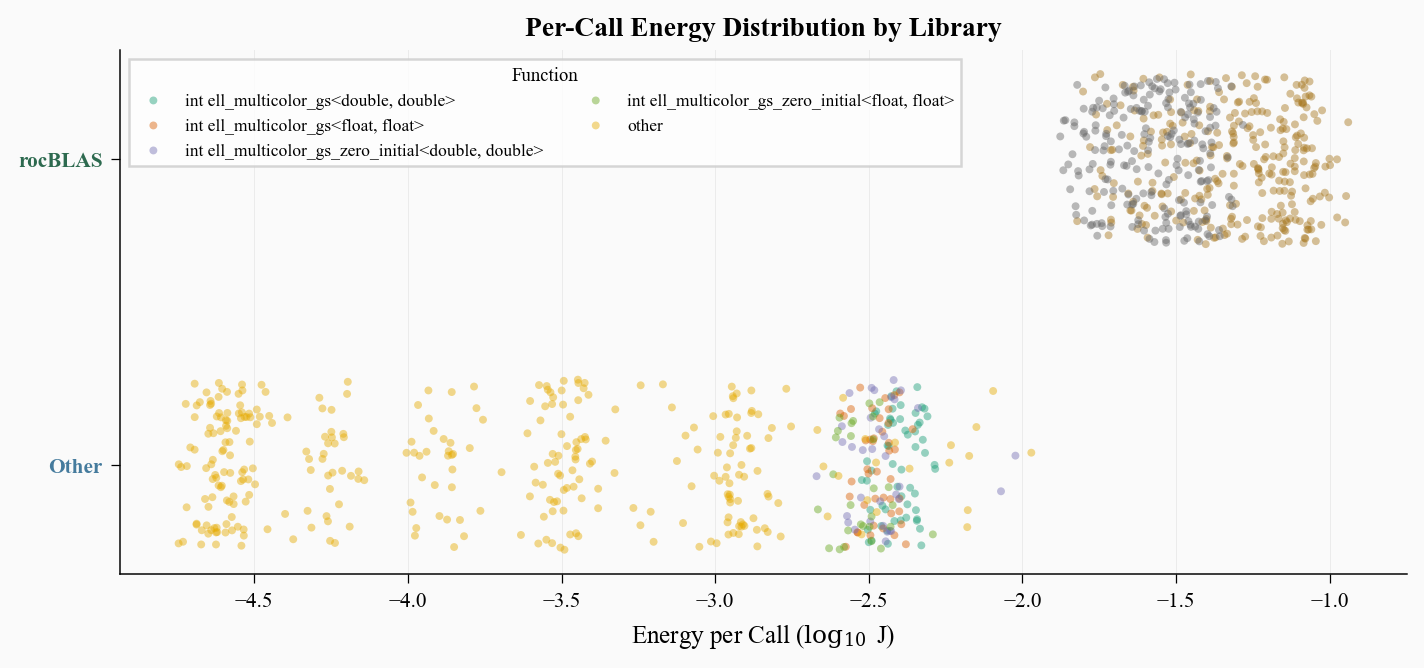

In [10]:
# -- Fig 6: Strip plot -- energy per call by library --

strip_df = compute_energy_sig[compute_energy_sig['Value'] > 0].copy()
strip_df['log_energy'] = np.log10(strip_df['Value'])

top_n_strip = 6
func_totals = strip_df.groupby('ShortName')['Value'].sum().sort_values(ascending=False)
top_funcs = func_totals.head(top_n_strip).index.tolist()
strip_df['FuncLabel'] = strip_df['ShortName'].where(
    strip_df['ShortName'].isin(top_funcs), 'other')

lib_median = strip_df.groupby('Library')['log_energy'].median().sort_values(ascending=True)
lib_plot_order = lib_median.index.tolist()

fig, ax = plt.subplots(figsize=(8, 3.8), facecolor=BG)
ax.set_facecolor(BG)

max_per_lib = 500
sampled = []
for lib in lib_plot_order:
    grp = strip_df[strip_df['Library'] == lib]
    sampled.append(grp.sample(n=min(len(grp), max_per_lib), random_state=42))
plot_df = pd.concat(sampled)

func_labels_unique = sorted(plot_df['FuncLabel'].unique())
n_labels = len(func_labels_unique)
func_cmap = plt.cm.Dark2 if n_labels <= 8 else plt.cm.tab20
func_colors = {f: func_cmap(i / max(n_labels - 1, 1))
               for i, f in enumerate(func_labels_unique)}

for i, lib in enumerate(lib_plot_order):
    sub = plot_df[plot_df['Library'] == lib]
    jitter = np.random.default_rng(42).uniform(-0.28, 0.28, size=len(sub))
    for fl in func_labels_unique:
        mask = sub['FuncLabel'] == fl
        if mask.sum() == 0:
            continue
        ax.scatter(sub.loc[mask, 'log_energy'], i + jitter[mask.values],
                   s=10, alpha=0.45, color=func_colors[fl],
                   edgecolors='none', label=fl if i == 0 else None,
                   rasterized=True)

ax.set_yticks(range(len(lib_plot_order)))
ax.set_yticklabels(lib_plot_order)
for j, lib in enumerate(lib_plot_order):
    ax.get_yticklabels()[j].set_color(LIB_PALETTE.get(lib, '#333'))
    ax.get_yticklabels()[j].set_fontweight('semibold')

ax.set_xlabel(r'Energy per Call ($\log_{10}$ J)')
ax.set_title('Per-Call Energy Distribution by Library', fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left',
          fontsize=7, frameon=True, fancybox=False, edgecolor='#ccc',
          title='Function', title_fontsize=7.5, ncol=2)
ax.grid(axis='x', alpha=0.2)

fig.tight_layout()
plt.savefig('fig6_strip_energy.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 7 -- Function Energy Landscape

Bubble chart: x = total compute time, y = mean power draw, bubble area = total energy.
Answers which functions run longest, draw the most power, and consume the most energy.

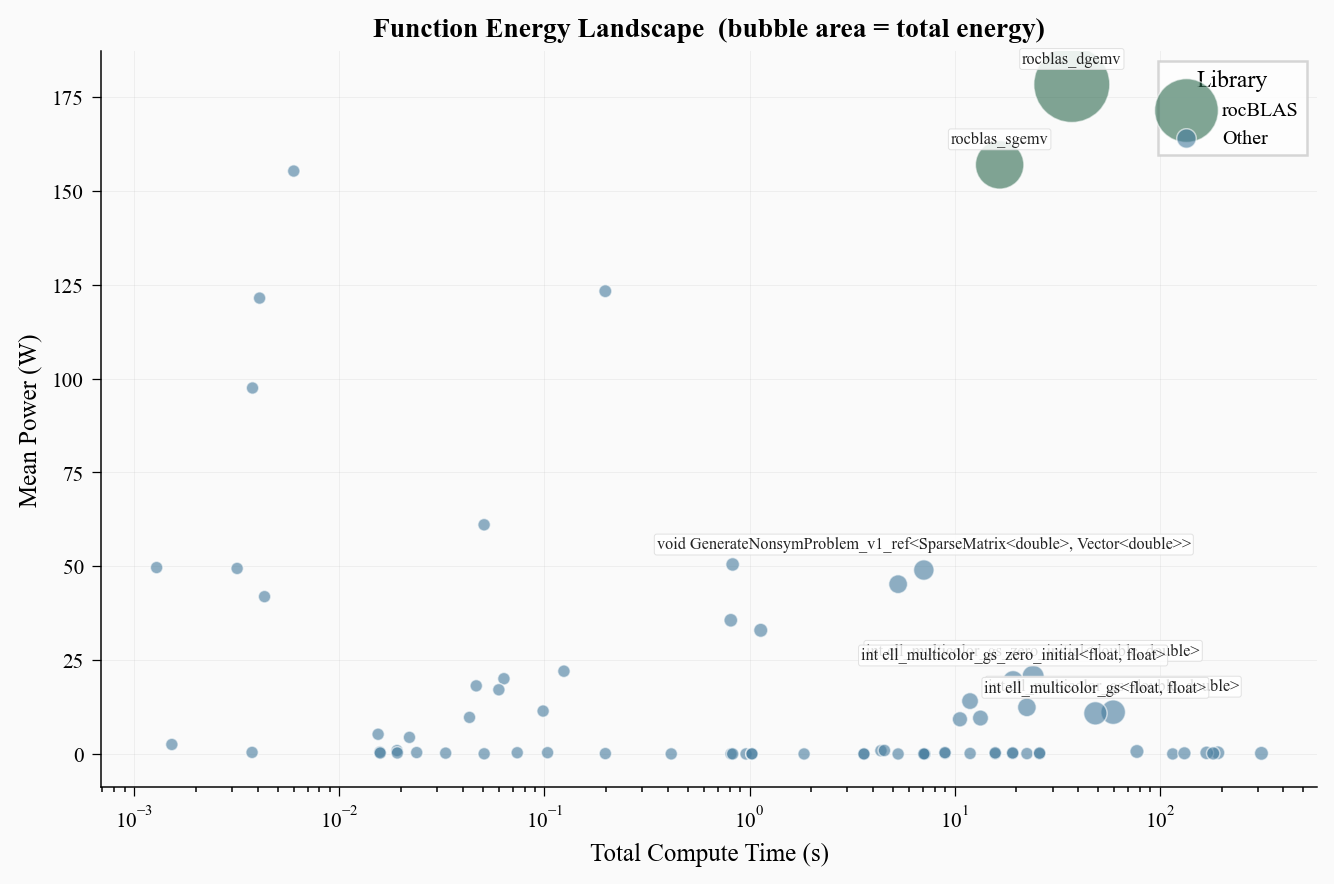

In [11]:
# -- Fig 7: Bubble chart -- Duration x Power x Energy --

func_agg = (compute_energy_sig.groupby('ShortName').agg(
    total_energy=('Value', 'sum'),
    total_time=('Duration', 'sum'),
    call_count=('Value', 'count'),
    library=('Library', 'first'),
).reset_index())

power_agg = compute_power_sig.groupby('ShortName')['Value'].mean().rename('mean_power')
func_agg = func_agg.merge(power_agg, on='ShortName', how='left').dropna(subset=['mean_power'])
func_agg = func_agg[func_agg['total_energy'] > func_agg['total_energy'].quantile(0.05)]

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=BG)
ax.set_facecolor(BG)

for lib in LIB_ORDER:
    sub = func_agg[func_agg['library'] == lib]
    if sub.empty:
        continue
    sizes = sub['total_energy'] / func_agg['total_energy'].max() * 900 + 25
    ax.scatter(sub['total_time'], sub['mean_power'], s=sizes,
               color=LIB_PALETTE[lib], alpha=0.6,
               edgecolors='white', linewidths=0.6, label=lib, zorder=3)

top_labels = func_agg.nlargest(7, 'total_energy')
for _, row in top_labels.iterrows():
    ax.annotate(row['ShortName'], (row['total_time'], row['mean_power']),
                fontsize=6.5, ha='center', va='bottom',
                xytext=(0, 7), textcoords='offset points', color='#222',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='#ddd',
                          alpha=0.85, linewidth=0.4))

ax.set_xlabel('Total Compute Time (s)')
ax.set_ylabel('Mean Power (W)')
ax.set_title('Function Energy Landscape  (bubble area = total energy)', fontweight='bold')
ax.legend(title='Library', frameon=True, fancybox=False, edgecolor='#ccc', fontsize=8)
ax.grid(alpha=0.15, zorder=0)

if func_agg['total_time'].max() / max(func_agg['total_time'].min(), 1e-9) > 50:
    ax.set_xscale('log')

fig.tight_layout()
plt.savefig('fig7_bubble_chart.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 8 -- Library Power Over Time

Stacked area showing which compute library is consuming GPU power at each
point in the execution.  Reveals application phases and library dominance.

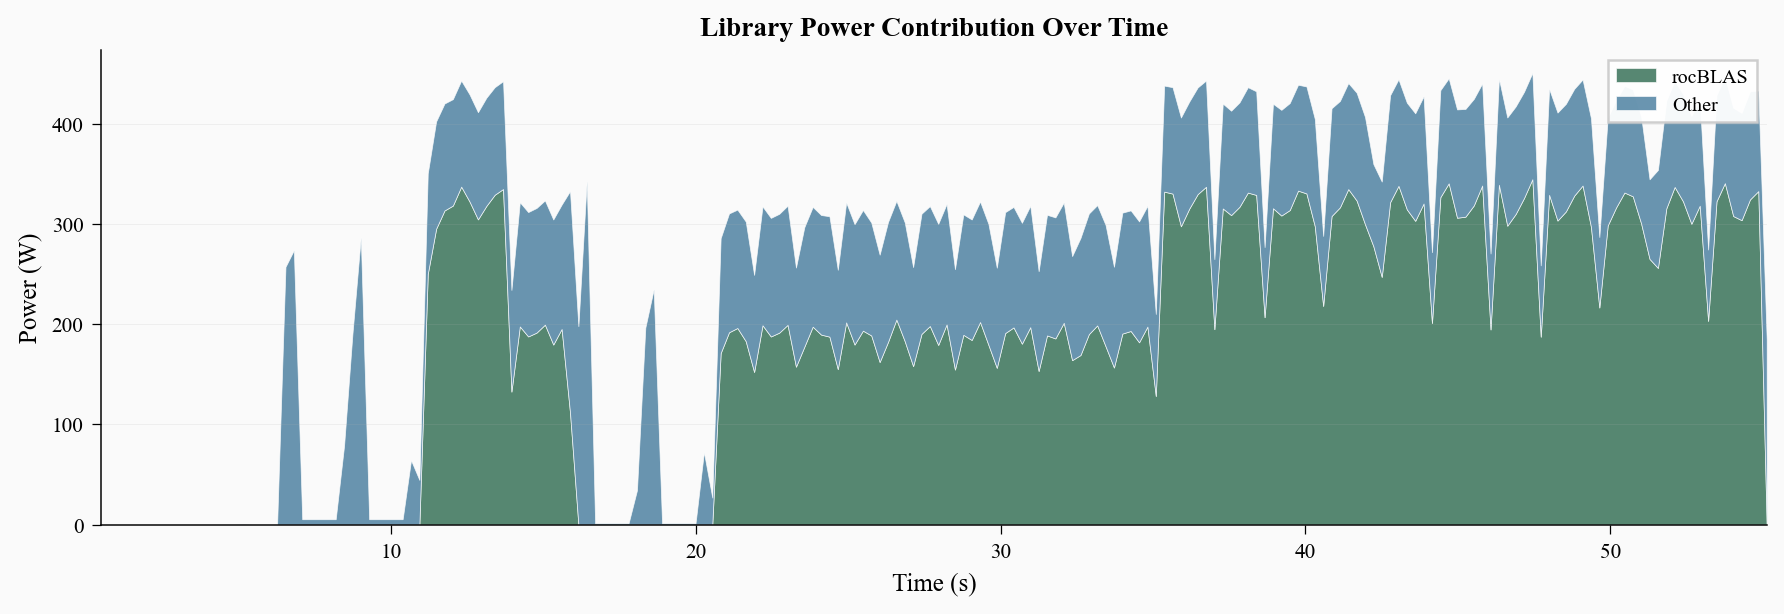

In [12]:
# -- Fig 8: Stacked area -- library power over time --

N_BINS_AREA = 200
t_min_a = compute_energy['Start Time'].min()
t_max_a = compute_energy['End Time'].max()
bin_edges_a = np.linspace(t_min_a, t_max_a, N_BINS_AREA + 1)
bin_centers_a = 0.5 * (bin_edges_a[:-1] + bin_edges_a[1:])
bin_width_a = bin_edges_a[1] - bin_edges_a[0]

area_libs = [l for l in LIB_ORDER if l in compute_energy['Library'].unique()]

lib_power_timeline = {}
for lib in area_libs:
    sub = compute_energy[compute_energy['Library'] == lib]
    bins = np.zeros(N_BINS_AREA)
    s_arr = sub['Start Time'].values
    e_arr = sub['End Time'].values
    v_arr = sub['Value'].values
    dur_arr = e_arr - s_arr
    ok = dur_arr > 0
    s_arr, e_arr, v_arr, dur_arr = s_arr[ok], e_arr[ok], v_arr[ok], dur_arr[ok]
    i0 = np.clip(np.searchsorted(bin_edges_a, s_arr, side='right') - 1, 0, N_BINS_AREA - 1)
    i1 = np.clip(np.searchsorted(bin_edges_a, e_arr, side='left'), 0, N_BINS_AREA)
    for j in range(len(s_arr)):
        for bi in range(i0[j], i1[j]):
            overlap = min(e_arr[j], bin_edges_a[bi+1]) - max(s_arr[j], bin_edges_a[bi])
            bins[bi] += v_arr[j] * overlap / dur_arr[j]
    lib_power_timeline[lib] = bins / bin_width_a

fig, ax = plt.subplots(figsize=(10, 3.5), facecolor=BG)
ax.set_facecolor(BG)

stack_data = np.array([lib_power_timeline[l] for l in area_libs])
colors = [LIB_PALETTE[l] for l in area_libs]
ax.stackplot(bin_centers_a, stack_data, labels=area_libs, colors=colors,
             alpha=0.80, edgecolor='white', linewidth=0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Power (W)')
ax.set_title('Library Power Contribution Over Time', fontweight='bold')
ax.legend(loc='upper right', frameon=True, fancybox=False,
          edgecolor='#ccc', framealpha=0.95, fontsize=8)
ax.set_xlim(bin_centers_a[0], bin_centers_a[-1])
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.15)

fig.tight_layout()
plt.savefig('fig8_stacked_area_power.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 9 -- Violin + Box: Power by Function

Full power distribution with quartile overlay for top energy consumers.

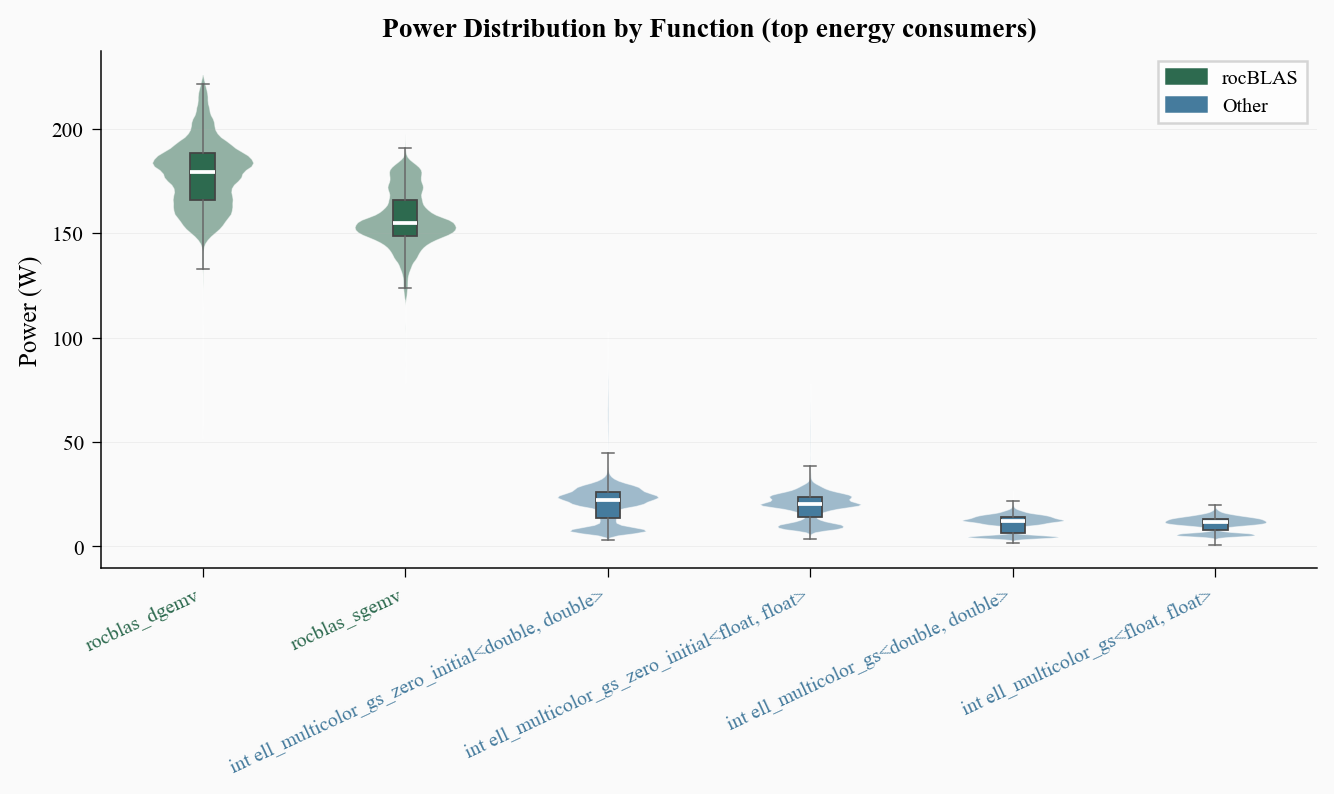

In [13]:
# -- Fig 9: Violin + box -- power by function --

top_funcs_violin = (compute_energy_sig.groupby('ShortName')['Value'].sum()
                    .sort_values(ascending=False).head(6).index.tolist())
violin_df = compute_power_sig[compute_power_sig['ShortName'].isin(top_funcs_violin)].copy()

med_order = (violin_df.groupby('ShortName')['Value']
             .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=BG)
ax.set_facecolor(BG)

func_lib_map = violin_df.groupby('ShortName')['Library'].first().to_dict()
palette = {f: LIB_PALETTE.get(func_lib_map.get(f, 'Other'), '#888') for f in med_order}
data_list = [violin_df[violin_df['ShortName'] == f]['Value'].values for f in med_order]

parts = ax.violinplot(data_list, positions=range(len(med_order)),
                      showmeans=False, showextrema=False, showmedians=False)
for pc, func in zip(parts['bodies'], med_order):
    pc.set_facecolor(palette[func])
    pc.set_edgecolor('white')
    pc.set_linewidth(0.4)
    pc.set_alpha(0.5)

bp = ax.boxplot(data_list, positions=range(len(med_order)),
                widths=0.12, patch_artist=True, showfliers=False, zorder=3)
for patch, func in zip(bp['boxes'], med_order):
    patch.set_facecolor(palette[func])
    patch.set_edgecolor('#444')
    patch.set_linewidth(0.7)
for el in ('whiskers', 'caps'):
    for line in bp[el]:
        line.set_color('#666')
        line.set_linewidth(0.6)
for line in bp['medians']:
    line.set_color('white')
    line.set_linewidth(1.5)

ax.set_xticks(range(len(med_order)))
ax.set_xticklabels(med_order, rotation=25, ha='right', fontsize=8)
for i, func in enumerate(med_order):
    ax.get_xticklabels()[i].set_color(palette[func])

ax.set_ylabel('Power (W)')
ax.set_title('Power Distribution by Function (top energy consumers)', fontweight='bold')
ax.grid(axis='y', alpha=0.15)

legend_libs = list(dict.fromkeys(func_lib_map[f] for f in med_order))
handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l) for l in legend_libs]
ax.legend(handles=handles, loc='upper right', frameon=True, fancybox=False,
          edgecolor='#ccc', fontsize=8)

fig.tight_layout()
plt.savefig('fig9_violin_power.pdf', bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 10 -- Treemap: Hierarchical Energy

Tile area = energy consumed.  Grouped by library, subdivided by function.

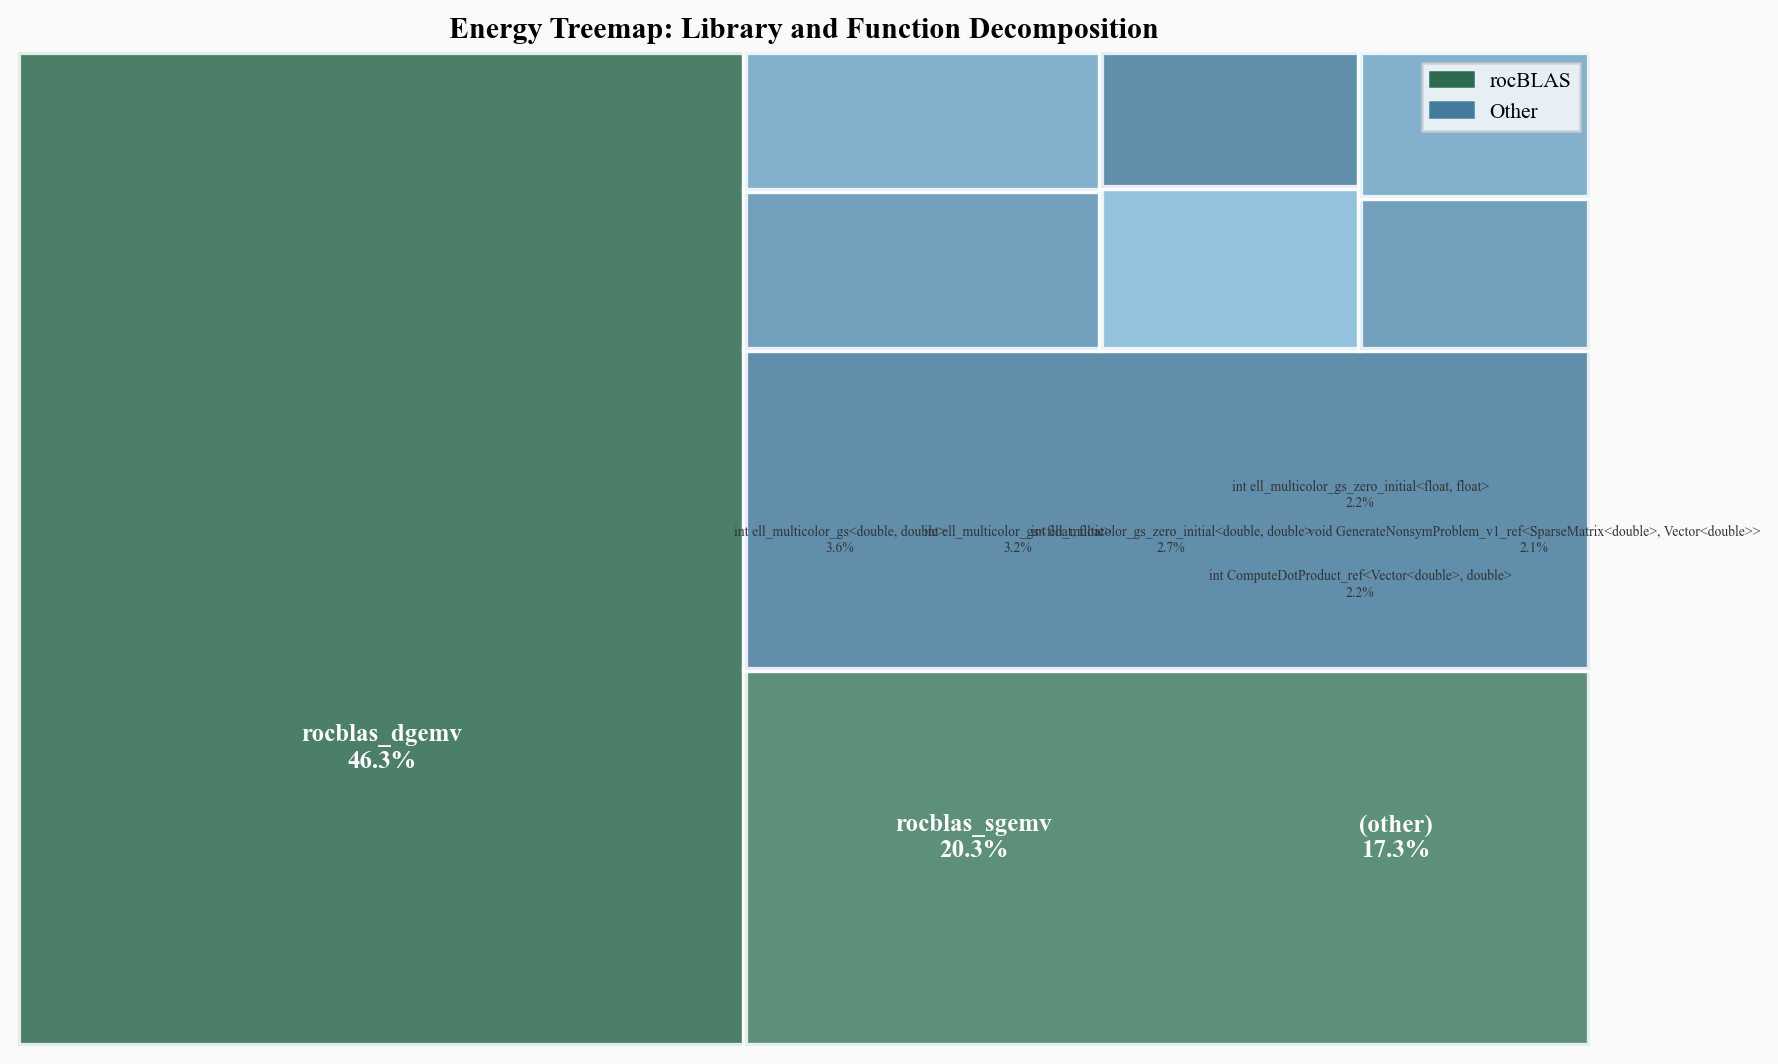

In [14]:
# -- Fig 10: Treemap -- library -> function energy --
import squarify

tree_data = (compute_energy.groupby(['Library', 'ShortName'])['Value']
             .sum().reset_index().sort_values('Value', ascending=False))

TOP_PER = 6
top_per_lib = tree_data.groupby('Library').head(TOP_PER)
other_rows = []
for lib in tree_data['Library'].unique():
    all_val = tree_data[tree_data['Library'] == lib]['Value'].sum()
    top_val = top_per_lib[top_per_lib['Library'] == lib]['Value'].sum()
    remainder = all_val - top_val
    if remainder > 0:
        other_rows.append({'Library': lib, 'ShortName': '(other)', 'Value': remainder})
tree_df = pd.concat([top_per_lib, pd.DataFrame(other_rows)], ignore_index=True)
tree_df = tree_df[tree_df['Value'] > 0]

lib_rank = {l: i for i, l in enumerate(LIB_ORDER)}
tree_df['_lr'] = tree_df['Library'].map(lib_rank).fillna(99)
tree_df = tree_df.sort_values(['_lr', 'Value'], ascending=[True, False])
total_area = tree_df['Value'].sum()

color_final = []
lib_counter = {}
for _, row in tree_df.iterrows():
    lib = row['Library']
    lib_counter[lib] = lib_counter.get(lib, 0)
    base = mcolors.to_rgb(LIB_PALETTE.get(lib, '#888'))
    factor = 0.08 * (lib_counter[lib] % 4)
    color_final.append(tuple(min(c + factor, 1.0) for c in base))
    lib_counter[lib] += 1

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

sizes = tree_df['Value'].tolist()
squarify.plot(sizes=sizes, label=None, color=color_final,
              alpha=0.85, edgecolor='white', linewidth=2.5, ax=ax)

rects = squarify.normalize_sizes(sizes, 100, 60)
rects = squarify.squarify(rects, 0, 0, 100, 60)
labels_list = tree_df['ShortName'].tolist()
for rect, label, sz in zip(rects, labels_list, sizes):
    frac = sz / total_area
    if frac < 0.015:
        continue
    cx = rect['x'] + rect['dx'] / 2
    cy = rect['y'] + rect['dy'] / 2
    fs = max(5.5, min(10, frac * 100))
    ax.text(cx, cy, f'{label}\n{frac*100:.1f}%',
            ha='center', va='center', fontsize=fs,
            color='white' if frac > 0.04 else '#333',
            fontweight='bold' if frac > 0.04 else 'normal')

handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l)
           for l in LIB_ORDER if l in tree_df['Library'].values]
ax.legend(handles=handles, loc='upper right', frameon=True, fancybox=False,
          edgecolor='#ccc', fontsize=8.5)
ax.set_title('Energy Treemap: Library and Function Decomposition',
             fontweight='bold', fontsize=12)
ax.axis('off')

fig.tight_layout()
plt.savefig('fig10_treemap.pdf', bbox_inches='tight', facecolor=BG)
plt.show()